# CEFR Multi-Prefix Tuning — 286M Variant

This notebook trains and evaluates the **~286M CEFR Multi-Prefix Tuning model** used in the thesis.

The model uses a frozen `meta-llama/Llama-3.1-8B-Instruct` backbone together with six CEFR-specific prefix banks corresponding to A1, A2, B1, B2, C1, and C2.

Each CEFR level is represented by 30 learned virtual tokens. Unlike the 68M parameter-matched variant, this configuration uses the full 4096-dimensional Llama hidden representation for the CEFR-specific prefix embeddings and shared prefix projection network.

The controller therefore implements:

`4096 → 4096 → 65536`

with a shared projection MLP and six CEFR-specific prefix banks.

The notebook includes:

- CEFR Multi-Prefix controller construction;
- training on the Balanced CEFR Steering Subset;
- validation-loss and perplexity tracking;
- hardware profiling;
- publication of the trained controller to Hugging Face;
- generation on the final In-Domain Evaluation Prompt Matrix;
- evaluation with the primary Joint-Loss CEFR evaluator.

The resulting controller contains **286,019,584 trainable parameters (~286.02M)**.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & DEPENDENCIES
# =========================================================
!pip install -q transformers peft torch datasets huggingface_hub accelerate scikit-learn textstat spacy hf_transfer "torchao>=0.16.0"
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import json
import math
import time
import threading
import pynvml
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_cosine_schedule_with_warmup,
    set_seed
)
from transformers.cache_utils import DynamicCache
from huggingface_hub import login, HfApi
from google.colab import drive, userdata
from tqdm.auto import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 103.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 123.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Ensure strict reproducibility
set_seed(42)
torch.backends.cudnn.deterministic = True

# Mount Storage Systems
drive.mount('/content/drive')

# Configuration Paths - CEFR Multi-Prefix Tuning
BALANCED_CSV_PATH = "/content/drive/MyDrive/Your_Path/"
    "balanced_cefr_steering_subset.csv"
HF_REPO_ID = "/content/drive/MyDrive/Your_Path/"
    "cefr_prefix_tuning_286m_training_logs"
DRIVE_LOG_DIR = "/content/drive/MyDrive/Mohammd_Thesis/Training_Logs/CEFR_Prefix_Tuning_6k"
LOCAL_OUTPUT_DIR = "./cefr_prefix_tuning_286m_export"

os.makedirs(DRIVE_LOG_DIR, exist_ok=True)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Using execution device: cuda
Device Name: NVIDIA A100-SXM4-80GB


In [ ]:
# =========================================================
# 1. INGEST BALANCED DATASET (6k STRATIFIED SPLIT)
# =========================================================
print(f"\n📥 Ingesting Training Dataset from: {BALANCED_CSV_PATH}")
df = pd.read_csv(BALANCED_CSV_PATH).dropna(subset=['cefr', 'clean_text', 'topic_title'])
df['cefr'] = df['cefr'].str.upper().str.strip()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
df['cefr_id'] = df['cefr'].map(label_map)
df = df.dropna(subset=['cefr_id'])
df['cefr_id'] = df['cefr_id'].astype(int)

train_df, val_df = train_test_split(
    df,
    test_size=0.10,
    stratify=df['cefr_id'],
    random_state=42
)

print(f"Training partition size:   {len(train_df):,} samples")
print(f"Validation partition size: {len(val_df):,} samples")


📥 Ingesting Training Dataset from: /content/drive/MyDrive/Mohammd_Thesis/subsets/efcamdat_balanced_subset_training.csv
Training partition size:   5,011 samples
Validation partition size: 557 samples


In [ ]:
# =========================================================
# 2. LOAD FROZEN BASE LLM & TOKENIZER
# =========================================================
model_id = "meta-llama/Llama-3.1-8B-Instruct"
print(f"\nLoading tokenizer and base model: {model_id}...")

# Right padding is required for causal language modeling during training
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": torch.cuda.current_device()}
)

# Strictly freeze the base Llama backbone
for param in base_model.parameters():
    param.requires_grad = False
base_model.eval()
base_model.config.use_cache = False



Loading tokenizer and base model: meta-llama/Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
# =========================================================
# 3. CEFR MULTI-PREFIX CONTROLLER ARCHITECTURE
# =========================================================
class CEFRMultiPrefixController(nn.Module):
    """
    Implements standard Prefix-Tuning where each of the 6 CEFR levels possesses
    its own dedicated 30 virtual-token embeddings. A shared MLP maps the selected
    tokens into layer-wise past key/value states.
    """
    def __init__(self, config, num_virtual_tokens=30, num_classes=6):
        super().__init__()
        self.num_virtual_tokens = num_virtual_tokens
        self.num_classes = num_classes
        self.num_layers = config.num_hidden_layers
        self.hidden_size = config.hidden_size
        self.num_kv_heads = config.num_key_value_heads
        self.head_dim = getattr(config, "head_dim", config.hidden_size // config.num_attention_heads)

        # 6 independent prefix token sets (6 levels * 30 virtual tokens = 180 distinct vectors)
        self.prefix_embeddings = nn.Embedding(
            num_classes * num_virtual_tokens,
            self.hidden_size
        )

        # Shared MLP reparameterization (Li & Liang, 2021)
        flat_out_dim = self.num_layers * 2 * self.num_kv_heads * self.head_dim
        self.prefix_mlp = nn.Sequential(
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.Tanh(),
            nn.Linear(self.hidden_size, flat_out_dim)
        )

    def forward(self, cefr_ids):
        batch_size = cefr_ids.shape[0]

        # Index the exact 30 virtual tokens belonging to the target level
        class_offsets = (cefr_ids * self.num_virtual_tokens).unsqueeze(1) # [B, 1]
        base_indices = torch.arange(self.num_virtual_tokens, device=cefr_ids.device).unsqueeze(0) # [1, 30]
        token_indices = class_offsets + base_indices # [B, 30]

        # [B, 30, 4096]
        prefix_tokens = self.prefix_embeddings(token_indices)

        # Shared MLP projection -> [B, 30, flat_out_dim]
        past_kv_flat = self.prefix_mlp(prefix_tokens)

        # Reshape to Llama-3.1 GQA past_key_values format
        past_kv = past_kv_flat.view(
            batch_size,
            self.num_virtual_tokens,
            self.num_layers,
            2,
            self.num_kv_heads,
            self.head_dim
        )
        # Permute to: [num_layers, 2, batch_size, kv_heads, num_virtual_tokens, head_dim]
        past_kv = past_kv.permute(2, 3, 0, 4, 1, 5)

        # Hugging Face transformers >=4.36 strictly require a Cache object instead of a tuple for get_query_offset
        past_key_values = DynamicCache()
        for i in range(self.num_layers):
            past_key_values.update(past_kv[i, 0], past_kv[i, 1], layer_idx=i)

        return past_key_values

prefix_controller = CEFRMultiPrefixController(base_model.config).to(device, dtype=torch.bfloat16)

trainable_params = sum(p.numel() for p in prefix_controller.parameters() if p.requires_grad)
print(f"Controller Trainable Parameters: {trainable_params:,} ({trainable_params / 1e6:.2f}M)")

Controller Trainable Parameters: 286,019,584 (286.02M)


In [ ]:
# =========================================================
# 4. DATASET UTILITY (BLIND INSTRUCTION PROMPT)
# =========================================================
class CEFRTopicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        topic_title = str(row['topic_title']).strip()

        # Blind Prompt: Explicit target CEFR level text is completely omitted
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{topic_title}'. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )

        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text = formatted_prompt + str(row['clean_text']).strip() + self.tokenizer.eos_token

        prompt_enc = self.tokenizer(
            formatted_prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length
        )
        prompt_len = len(prompt_enc['input_ids'])

        full_enc = self.tokenizer(
            full_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
            padding='max_length'
        )

        input_ids = torch.tensor(full_enc['input_ids'], dtype=torch.long)
        attention_mask = torch.tensor(full_enc['attention_mask'], dtype=torch.long)

        # Rigorous Masking: Prompt tokens and padding positions receive -100
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "cefr_id": torch.tensor(row['cefr_id'], dtype=torch.long)
        }

TRAIN_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2   # Effective batch size = 32
VAL_BATCH_SIZE = 32

train_loader = DataLoader(
    CEFRTopicDataset(train_df, tokenizer),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
val_loader = DataLoader(
    CEFRTopicDataset(val_df, tokenizer),
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [ ]:
# =========================================================
# 5. HARDWARE PROFILER (BACKGROUND NVML DAEMON)
# =========================================================
class GPUMonitor(threading.Thread):
    def __init__(self, delay=1.0):
        super(GPUMonitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.utilization_rates = []
        pynvml.nvmlInit()
        self.handle = pynvml.nvmlDeviceGetHandleByIndex(0)

    def run(self):
        while not self.stopped:
            try:
                util = pynvml.nvmlDeviceGetUtilizationRates(self.handle)
                self.utilization_rates.append(util.gpu)
            except Exception:
                pass
            time.sleep(self.delay)

    def stop(self):
        self.stopped = True
        try:
            pynvml.nvmlShutdown()
        except Exception:
            pass

    def get_avg_utilization(self):
        if not self.utilization_rates: return 0.0
        return sum(self.utilization_rates) / len(self.utilization_rates)

In [ ]:
# =========================================================
# 6. OPTIMIZATION & TRAINING LOOP
# =========================================================
epochs = 3
lr = 2e-4
optimizer = torch.optim.AdamW(prefix_controller.parameters(), lr=lr, weight_decay=0.01)

total_training_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * epochs
warmup_steps = int(0.05 * total_training_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

best_val_loss = float('inf')
training_summary_logs = []

print(f"\n🚀 Launching CEFR Multi-Prefix Tuning across {epochs} Epochs...")

torch.cuda.reset_peak_memory_stats()
gpu_monitor = GPUMonitor(delay=1.0)
gpu_monitor.start()
start_time = time.perf_counter()

for epoch in range(epochs):
    prefix_controller.train()
    running_train_loss = 0.0
    optimizer.zero_grad()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        cefr_ids = batch['cefr_id'].to(device)

        # 1. Retrieve level-specific past_key_values as a DynamicCache
        past_key_values = prefix_controller(cefr_ids)

        # 2. Extend attention mask for prefix tokens
        prefix_mask = torch.ones(
            input_ids.shape[0],
            prefix_controller.num_virtual_tokens,
            dtype=attention_mask.dtype,
            device=device
        )
        full_attention_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        # 3. Explicit position_ids starting after prefix boundary
        position_ids = full_attention_mask.long().cumsum(-1) - 1
        position_ids.masked_fill_(full_attention_mask == 0, 1)
        position_ids = position_ids[:, prefix_controller.num_virtual_tokens:]

        # 4. Standard forward pass
        outputs = base_model(
            input_ids=input_ids,
            attention_mask=full_attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            labels=labels
        )
        loss = outputs.loss

        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        running_train_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(prefix_controller.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({"Loss": f"{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}"})

    # Validation Loop
    prefix_controller.eval()
    val_loss_accum = 0.0
    val_steps = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            cefr_ids = batch['cefr_id'].to(device)

            past_key_values = prefix_controller(cefr_ids)
            prefix_mask = torch.ones(
                input_ids.shape[0],
                prefix_controller.num_virtual_tokens,
                dtype=attention_mask.dtype,
                device=device
            )
            full_attention_mask = torch.cat([prefix_mask, attention_mask], dim=1)

            position_ids = full_attention_mask.long().cumsum(-1) - 1
            position_ids.masked_fill_(full_attention_mask == 0, 1)
            position_ids = position_ids[:, prefix_controller.num_virtual_tokens:]

            outputs = base_model(
                input_ids=input_ids,
                attention_mask=full_attention_mask,
                position_ids=position_ids,
                past_key_values=past_key_values,
                labels=labels
            )
            val_loss_accum += outputs.loss.item()
            val_steps += 1

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = val_loss_accum / val_steps
    val_ppl = float(np.exp(avg_val_loss))

    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": round(avg_train_loss, 4),
        "val_loss": round(avg_val_loss, 4),
        "val_ppl": round(val_ppl, 2)
    }
    training_summary_logs.append(epoch_metrics)

    print(f"\n📈 [Epoch {epoch+1}/{epochs}] Done | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        checkpoint_path = os.path.join(LOCAL_OUTPUT_DIR, "cefr_prefix_tuning_best_weights.pt")
        torch.save(prefix_controller.state_dict(), checkpoint_path)
        print(f"🌟 Best validation score achieved! Saved checkpoint to {checkpoint_path}")

    torch.cuda.empty_cache()
    gc.collect()

gpu_monitor.stop()
end_time = time.perf_counter()

# Save training summary JSON locally and to Google Drive
json_log_path = os.path.join(DRIVE_LOG_DIR, "cefr_prefix_tuning_training_summary_6k.json")
with open(json_log_path, "w") as f:
    json.dump(training_summary_logs, f, indent=4)
with open(os.path.join(LOCAL_OUTPUT_DIR, "training_summary_6k.json"), "w") as f:
    json.dump(training_summary_logs, f, indent=4)

total_time_seconds = end_time - start_time
total_time_hours = total_time_seconds / 3600
avg_gpu_util = gpu_monitor.get_avg_utilization()
peak_vram_gb = torch.cuda.max_memory_allocated() / (1024**3)

profiling_report = (
    "=== CEFR Multi-Prefix Tuning Hardware Profiling Report (6k Balanced) ===\n"
    f"Total training time: {total_time_seconds:.2f} seconds ({total_time_hours:.2f} hours)\n"
    f"Peak GPU memory: {peak_vram_gb:.2f} GB\n"
    f"Average GPU utilization: {avg_gpu_util:.1f}%\n"
)
print("\n" + profiling_report)



🚀 Launching CEFR Multi-Prefix Tuning across 3 Epochs...


Epoch 1/3 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


📈 [Epoch 1/3] Done | Train Loss: 2.6608 | Val Loss: 2.5036 | Val PPL: 12.23
🌟 Best validation score achieved! Saved checkpoint to ./cefr_prefix_tuning_6k_export/cefr_prefix_tuning_best_weights.pt


Epoch 2/3 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 2/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


📈 [Epoch 2/3] Done | Train Loss: 2.3967 | Val Loss: 2.4328 | Val PPL: 11.39
🌟 Best validation score achieved! Saved checkpoint to ./cefr_prefix_tuning_6k_export/cefr_prefix_tuning_best_weights.pt


Epoch 3/3 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


📈 [Epoch 3/3] Done | Train Loss: 2.2449 | Val Loss: 2.4366 | Val PPL: 11.43

=== CEFR Multi-Prefix Tuning Hardware Profiling Report (6k Balanced) ===
Total training time: 1497.77 seconds (0.42 hours)
Peak GPU memory: 69.43 GB
Average GPU utilization: 97.4%



In [ ]:
# =========================================================
# 7. EXPORT TO HUGGING FACE
# =========================================================

tokenizer.save_pretrained(LOCAL_OUTPUT_DIR)

readme_content = f"""---
license: apache-2.0
base_model: {model_id}
tags:
- prefix-tuning
- cefr-control
- multi-prefix
- topic-aligned
---

# CEFR Multi-Prefix Tuning Baseline (Llama-3.1-8B-Instruct)

This repository contains the trained weights for CEFR-Conditioned Multi-Prefix Tuning.

Instead of passing target proficiency instructions in the textual prompt, the model assigns 30 dedicated continuous virtual tokens to each of the six CEFR proficiency levels (A1 to C2).

## Architecture Details

- **Conditioning Mechanism**: 6 independent prefix embedding sets ($6 \\\\times 30 = 180$ virtual token vectors in $\\\\mathbb{{R}}^{{4096}}$).
- **Reparameterization**: Shared two-layer MLP mapping the selected 30 vectors to layer-wise past key/values.
- **Attention Normalization**: Virtual tokens enter the self-attention mechanism as key/value states, undergoing standard softmax normalization alongside context tokens (Li & Liang, 2021).
- **Textual Prompt**: Blind instruction (contains no target CEFR level tokens).
- **Backbone**: Frozen `meta-llama/Llama-3.1-8B-Instruct` (8B parameters).

## Training Performance

{json.dumps(training_summary_logs, indent=2)}

## Hardware Profiling

- **Total training time**: {total_time_seconds:.2f} seconds ({total_time_hours:.2f} hours)
- **Peak GPU memory**: {peak_vram_gb:.2f} GB
- **Average GPU utilization**: {avg_gpu_util:.1f}%
"""

# ---------------------------------------------------------
# Save README
# ---------------------------------------------------------

readme_path = os.path.join(LOCAL_OUTPUT_DIR, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print(f"✅ README saved to: {readme_path}")

# ---------------------------------------------------------
# Push controller checkpoint to Hugging Face Hub
# ---------------------------------------------------------

print("\n📦 Pushing controller checkpoint to Hugging Face repository...")

try:
    api = HfApi()

    # Create repository if it does not already exist
    api.create_repo(
        repo_id=HF_REPO_ID,
        repo_type="model",
        exist_ok=True
    )

    # Upload controller weights, tokenizer, configuration, and README
    api.upload_folder(
        folder_path=LOCAL_OUTPUT_DIR,
        repo_id=HF_REPO_ID,
        repo_type="model",
        commit_message=(
            f"Upload CEFR Multi-Prefix Tuning weights "
            f"(Val PPL: {np.exp(best_val_loss):.2f})"
        )
    )

    print(
        f"🚀 SUCCESS! Model weights deployed to:\n"
        f"https://huggingface.co/{HF_REPO_ID}"
    )

except Exception as e:
    print(f"⚠️ Export failed: {str(e)}")

✅ README saved to: ./cefr_prefix_tuning_6k_export/README.md

📦 Pushing controller checkpoint to Hugging Face repository...
🚀 SUCCESS! Model weights deployed to:
https://huggingface.co/MohammadKhosravi/llama3.1-8b-cefr-prefix-tuning-6k


## CEFR Multi-Prefix Generation and Evaluation

This section loads the trained 286M CEFR Multi-Prefix controller and evaluates it on the final In-Domain Evaluation Prompt Matrix.

The textual prompt does not explicitly contain the target CEFR label. Instead, the requested proficiency level is supplied through the corresponding CEFR-specific prefix bank.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & DEPENDENCIES
# =========================================================
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy hf_transfer "torchao>=0.16.0"
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error
)

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    set_seed
)

from transformers.cache_utils import DynamicCache
from huggingface_hub import login, hf_hub_download
from google.colab import drive, userdata
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 101.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 137.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# =========================================================
# REPRODUCIBILITY
# =========================================================
set_seed(42)
torch.backends.cudnn.deterministic = True

# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================
drive.mount('/content/drive')

# =========================================================
# PATHS
# =========================================================
INPUT_CSV = (
    "/content/drive/MyDrive/Your_Path/"
    "in_domain_evaluation_prompt_matrix.csv"
)

OUTPUT_DIR = (
    "/content/drive/MyDrive/Your_Path/"
    "cefr_prefix_tuning_286m_evaluation_results"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "cefr_prefix_benchmark_results_log.csv"
)

OUTPUT_TXT_PATH = os.path.join(
    OUTPUT_DIR,
    "cefr_prefix_overall_metrics_report.txt"
)

OUTPUT_IMG_PATH = os.path.join(
    OUTPUT_DIR,
    "cefr_prefix_confusion_matrix.png"
)

# =========================================================
# HUGGING FACE LOGIN
# =========================================================
try:
    hf_token = userdata.get("HF_TOKEN")
    login(token=hf_token)
except Exception:
    pass

# =========================================================
# GLOBAL CONFIGURATION
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 32
MAX_NEW_TOKENS = 200
TEMPERATURE = 0.6

label_map = {
    "A1": 0,
    "A2": 1,
    "B1": 2,
    "B2": 3,
    "C1": 4,
    "C2": 5
}

inv_label_map = {
    v: k for k, v in label_map.items()
}

print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:
# =========================================================
# 1. LOAD BASE MODEL & CONTROLLER
# =========================================================
print(
    "\n[1/3] Loading Llama-3.1-8B and "
    "CEFR Multi-Prefix Controller..."
)

model_id = "meta-llama/Llama-3.1-8B-Instruct"

# ---------------------------------------------------------
# TOKENIZER
# ---------------------------------------------------------
# Left padding is used for batched decoder-only generation.
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    padding_side="left"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# ---------------------------------------------------------
# BASE MODEL
# ---------------------------------------------------------
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

base_model.eval()
base_model.config.use_cache = True


[1/3] Loading Llama-3.1-8B and CEFR Multi-Prefix Controller...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
# ---------------------------------------------------------
# CEFR MULTI-PREFIX CONTROLLER
# ---------------------------------------------------------
class CEFRMultiPrefixController(nn.Module):
    """
    Standard Prefix-Tuning-style controller with six
    independent CEFR-specific prefix sets.

    Each CEFR level owns 30 independent virtual-token
    embeddings. A shared MLP maps those embeddings to
    layer-wise key/value states for Llama-3.1's GQA
    attention.
    """

    def __init__(
        self,
        config,
        num_virtual_tokens=30,
        num_classes=6
    ):
        super().__init__()

        self.num_virtual_tokens = num_virtual_tokens
        self.num_classes = num_classes

        self.num_layers = config.num_hidden_layers
        self.hidden_size = config.hidden_size

        self.num_kv_heads = config.num_key_value_heads

        self.head_dim = getattr(
            config,
            "head_dim",
            config.hidden_size // config.num_attention_heads
        )

        # -------------------------------------------------
        # Six independent prefix sets:
        # 6 × 30 = 180 distinct virtual-token embeddings
        # -------------------------------------------------
        self.prefix_embeddings = nn.Embedding(
            num_classes * num_virtual_tokens,
            self.hidden_size
        )

        # -------------------------------------------------
        # Shared Prefix-Tuning reparameterization MLP
        # -------------------------------------------------
        flat_out_dim = (
            self.num_layers
            * 2
            * self.num_kv_heads
            * self.head_dim
        )

        self.prefix_mlp = nn.Sequential(
            nn.Linear(
                self.hidden_size,
                self.hidden_size
            ),
            nn.Tanh(),
            nn.Linear(
                self.hidden_size,
                flat_out_dim
            )
        )

    def forward(self, cefr_ids):

        batch_size = cefr_ids.shape[0]

        # -------------------------------------------------
        # Select the 30 prefix embeddings corresponding
        # to each CEFR level
        # -------------------------------------------------
        class_offsets = (
            cefr_ids * self.num_virtual_tokens
        ).unsqueeze(1)

        base_indices = torch.arange(
            self.num_virtual_tokens,
            device=cefr_ids.device
        ).unsqueeze(0)

        token_indices = (
            class_offsets + base_indices
        )

        # [B, 30, 4096]
        prefix_tokens = self.prefix_embeddings(
            token_indices
        )

        # [B, 30, flat_out_dim]
        past_kv_flat = self.prefix_mlp(
            prefix_tokens
        )

        # -------------------------------------------------
        # Reshape into Llama GQA KV representation
        # -------------------------------------------------
        past_kv = past_kv_flat.view(
            batch_size,
            self.num_virtual_tokens,
            self.num_layers,
            2,
            self.num_kv_heads,
            self.head_dim
        )

        # [num_layers, 2, B, kv_heads, 30, head_dim]
        past_kv = past_kv.permute(
            2, 3, 0, 4, 1, 5
        )

        # -------------------------------------------------
        # Build DynamicCache
        # -------------------------------------------------
        past_key_values = DynamicCache()

        for layer_idx in range(self.num_layers):

            past_key_values.update(
                past_kv[layer_idx, 0],
                past_kv[layer_idx, 1],
                layer_idx=layer_idx
            )

        return past_key_values


# ---------------------------------------------------------
# INITIALIZE CONTROLLER
# ---------------------------------------------------------
prefix_controller = CEFRMultiPrefixController(
    base_model.config
).to(
    device,
    dtype=torch.bfloat16
)

# ---------------------------------------------------------
# LOAD TRAINED CONTROLLER
# ---------------------------------------------------------
print(
    "Downloading CEFR Multi-Prefix controller "
    "parameter weights from Hub..."
)

weights_path = hf_hub_download(
    repo_id=(
        "MohammadKhosravi/"
        "llama3.1-8b-cefr-prefix-tuning-6k"
    ),
    filename="cefr_prefix_tuning_best_weights.pt"
)

state_dict = torch.load(
    weights_path,
    map_location=device
)

prefix_controller.load_state_dict(state_dict)
prefix_controller.eval()

print("✔️ CEFR Prefix-Tuning controller loaded.")

# =========================================================
# 2. PHASE 1: GENERATION
# =========================================================
print("\n[2/3] Initiating Batch Generation Phase...")

df = pd.read_csv(INPUT_CSV)

generated_records = []

for b_start in tqdm(
    range(0, len(df), BATCH_SIZE),
    desc="Processing Prompt Batches"
):

    batch_df = df.iloc[
        b_start:b_start + BATCH_SIZE
    ]

    batch_prompts = []
    batch_cefrs = []

    # -----------------------------------------------------
    # BUILD BLIND PROMPTS
    # -----------------------------------------------------
    for _, row in batch_df.iterrows():

        t_cefr = str(
            row["cefr"]
        ).strip().upper()

        batch_cefrs.append(t_cefr)

        # IMPORTANT:
        # Target CEFR is intentionally NOT present
        # in the textual prompt.
        prompt = (
            "You are an expert English language teacher "
            "demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, "
            f"grammatically correct text responding to "
            f"this prompt: '{row['topic_title']}'. "
            "If the requested target level is A1/A2, "
            "use very simple vocabulary, short sentences, "
            "and primitive structures. "
            "If the requested target level is C1/C2, "
            "utilize highly advanced vocabulary, idioms, "
            "and complex sentence patterns. "
            "Write only the direct response. "
            "Do not write any meta-commentary, greetings, "
            "or conversational pleasantries."
        )

        messages = [
            {
                "role": "user",
                "content": prompt
            }
        ]

        formatted_prompt = (
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
        )

        batch_prompts.append(formatted_prompt)

    # -----------------------------------------------------
    # TOKENIZE
    # -----------------------------------------------------
    inputs = tokenizer(
        batch_prompts,
        padding=True,
        return_tensors="pt"
    ).to(device)

    # -----------------------------------------------------
    # CEFR IDS
    # -----------------------------------------------------
    cefr_tensor = torch.tensor(
        [
            label_map[c]
            for c in batch_cefrs
        ],
        dtype=torch.long,
        device=device
    )

    batch_size = inputs.input_ids.shape[0]
    prompt_length = inputs.input_ids.shape[1]

    with torch.inference_mode():

        # =================================================
        # 2.1 BUILD CEFR-SPECIFIC PREFIX CACHE
        # =================================================
        past_key_values = prefix_controller(
            cefr_tensor
        )

        num_virtual_tokens = (
            prefix_controller.num_virtual_tokens
        )

        # =================================================
        # 2.2 BUILD PREFIX + PROMPT ATTENTION MASK
        # =================================================
        #
        # The DynamicCache already contains the 30 virtual
        # prefix positions.
        #
        # Therefore we DO NOT add dummy input tokens.
        #
        # The attention mask must nevertheless represent
        # both:
        #
        #   [30 prefix positions] + [textual prompt]
        #
        # =================================================
        prefix_mask = torch.ones(
            batch_size,
            num_virtual_tokens,
            dtype=inputs.attention_mask.dtype,
            device=device
        )

        full_attention_mask = torch.cat(
            [
                prefix_mask,
                inputs.attention_mask
            ],
            dim=1
        )

        # =================================================
        # 2.3 POSITION IDS
        # =================================================
        #
        # Match the positional convention used during
        # training:
        #
        # prefix positions occupy the first 30 positions,
        # and the textual prompt starts after them.
        #
        position_ids = (
            full_attention_mask.long().cumsum(-1) - 1
        )

        position_ids.masked_fill_(
            full_attention_mask == 0,
            1
        )

        # Keep only positions belonging to actual input_ids
        position_ids = position_ids[
            :,
            num_virtual_tokens:
        ]

        # =================================================
        # 2.4 CACHE POSITION
        # =================================================
        #
        # The prefix cache already contains 30 positions.
        # Therefore the textual prompt occupies cache
        # positions [30, 31, ..., 30 + prompt_length - 1].
        #
        # cache_position is independent of padding.
        # =================================================
        cache_position = torch.arange(
            num_virtual_tokens,
            num_virtual_tokens + prompt_length,
            dtype=torch.long,
            device=device
        )

        # =================================================
        # 2.5 PREFILL PROMPT
        # =================================================
        #
        # This processes the actual textual prompt while
        # keeping the CEFR prefix KV states in the cache.
        # =================================================
        outputs = base_model(
            input_ids=inputs.input_ids,
            attention_mask=full_attention_mask,
            position_ids=position_ids,
            cache_position=cache_position,
            past_key_values=past_key_values,
            use_cache=True
        )

        # =================================================
        # 2.6 SAMPLE FIRST GENERATED TOKEN
        # =================================================
        logits = outputs.logits[:, -1, :]

        logits = logits / TEMPERATURE

        probs = torch.softmax(
            logits,
            dim=-1
        )

        next_tokens = torch.multinomial(
            probs,
            num_samples=1
        )

        # Store only generated tokens.
        generated_tokens = [
            next_tokens
        ]

        # Track sequences that have generated EOS.
        finished = (
            next_tokens.squeeze(1)
            == tokenizer.eos_token_id
        )

        # Current total cached sequence length:
        # 30 prefix + prompt_length
        current_cache_length = (
            num_virtual_tokens
            + prompt_length
        )

        # Attention mask for subsequent decoding.
        current_attention_mask = full_attention_mask

        # =================================================
        # 2.7 AUTOREGRESSIVE DECODING
        # =================================================
        for step in range(1, MAX_NEW_TOKENS):

            # -------------------------------------------------
            # Once a sequence has finished, feed PAD instead
            # of continuing to sample it.
            # -------------------------------------------------
            input_token = next_tokens.clone()

            input_token[
                finished
            ] = tokenizer.pad_token_id

            # -------------------------------------------------
            # Append one position to attention mask.
            #
            # Active sequences: 1
            # Finished sequences: 0
            #
            # This prevents generated PAD positions from
            # contributing attention for finished sequences.
            # -------------------------------------------------
            new_attention_values = (
                (~finished).long().unsqueeze(1)
            )

            current_attention_mask = torch.cat(
                [
                    current_attention_mask,
                    new_attention_values
                ],
                dim=1
            )

            # -------------------------------------------------
            # Position ID of the newly processed token.
            #
            # Since the cache already contains
            # current_cache_length positions, the next token
            # occupies that position.
            # -------------------------------------------------
            next_position_id = torch.full(
                (batch_size, 1),
                current_cache_length,
                dtype=torch.long,
                device=device
            )

            # -------------------------------------------------
            # Cache position of the newly processed token.
            # -------------------------------------------------
            next_cache_position = torch.tensor(
                [current_cache_length],
                dtype=torch.long,
                device=device
            )

            # -------------------------------------------------
            # Forward only the newly generated token.
            # -------------------------------------------------
            outputs = base_model(
                input_ids=input_token,
                attention_mask=current_attention_mask,
                position_ids=next_position_id,
                cache_position=next_cache_position,
                past_key_values=past_key_values,
                use_cache=True
            )

            # -------------------------------------------------
            # Sample next token.
            # -------------------------------------------------
            logits = outputs.logits[:, -1, :]

            logits = logits / TEMPERATURE

            probs = torch.softmax(
                logits,
                dim=-1
            )

            sampled_tokens = torch.multinomial(
                probs,
                num_samples=1
            )

            # -------------------------------------------------
            # Preserve PAD after EOS.
            # -------------------------------------------------
            next_tokens = torch.where(
                finished.unsqueeze(1),
                torch.full_like(
                    sampled_tokens,
                    tokenizer.pad_token_id
                ),
                sampled_tokens
            )

            generated_tokens.append(
                next_tokens
            )

            # -------------------------------------------------
            # Update finished state.
            # -------------------------------------------------
            newly_finished = (
                next_tokens.squeeze(1)
                == tokenizer.eos_token_id
            )

            finished = finished | newly_finished

            # One more token is now represented in the cache.
            current_cache_length += 1

            # Stop the entire batch if every sequence ended.
            if finished.all():
                break

        # -----------------------------------------------------
        # Stack generated tokens:
        #
        # [batch_size, generated_length]
        # -----------------------------------------------------
        generated_tokens = torch.cat(
            generated_tokens,
            dim=1
        )

    # =====================================================
    # 2.8 DECODE ONLY GENERATED TOKENS
    # =====================================================
    for i in range(batch_size):

        gen_text = tokenizer.decode(
            generated_tokens[i],
            skip_special_tokens=True
        ).strip()

        generated_records.append(
            {
                "topic_id": batch_df.iloc[i]["topic_id"],
                "topic_title": batch_df.iloc[i]["topic_title"],
                "target_cefr": batch_cefrs[i],
                "generated_text": gen_text
            }
        )

# =========================================================
# FREE GENERATION MEMORY
# =========================================================
del base_model
del prefix_controller

torch.cuda.empty_cache()
gc.collect()



cefr_prefix_tuning_best_weights.pt: reconstructing file:   0%|          |  0.00B /  572MB            

cefr_prefix_tuning_best_weights.pt: downloading bytes:           |  0.00B            

✔️ CEFR Prefix-Tuning controller loaded.

[2/3] Initiating Batch Generation Phase...


Processing Prompt Batches: 100%|██████████| 22/22 [09:47<00:00, 26.73s/it]


202


[3/3] Initiating Post-Generation Evaluation Loop...
Deploying Custom JointLoss RoBERTa Evaluator Matrix...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Extracting Metrics: 100%|██████████| 702/702 [00:55<00:00, 12.66it/s]


✔️ Benchmark log saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/CEFR_Prefix_Tuning_6k_Baseline/cefr_prefix_benchmark_results_log.csv
 📊 FINAL COMPILED MACRO-STATISTICS (CEFR MULTI-PREFIX 6k)
Total Processed       : 702
Strict Accuracy       : 52.42%
Adjacent Accuracy     : 76.35%
Mean Abs Error (MAE)  : 0.8533
Avg MDD Score         : 1.82
Avg Reading Ease      : 79.49
Avg Sentence Drift    : 2.34 levels
Avg Perplexity        : (Computed externally)

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     71.79     1.61       83.44       0.89
A2                     50.43     1.63       82.97       1.82
B1                     60.68     1.88       79.65       2.42
B2                     59.83     1.93       74.88       2.72
C1                     42.74     1.95       76.27       2.96
C2                     29.06     1.93       79.72       3.26

📝 

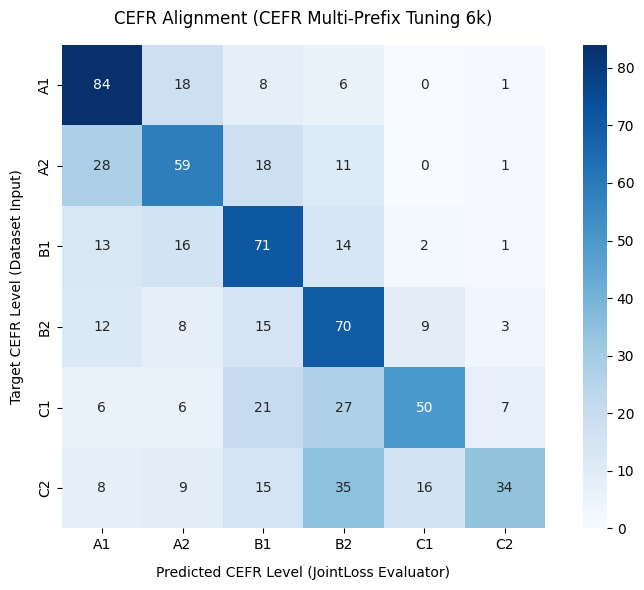

In [ ]:
# =========================================================
# 3. PHASE 2: EVALUATION & LINGUISTIC METRICS
# =========================================================
print(
    "\n[3/3] Initiating Post-Generation Evaluation Loop..."
)

nlp = spacy.load("en_core_web_sm")

print(
    "Deploying Custom JointLoss RoBERTa Evaluator Matrix..."
)

JUDGE_MODEL_ID = (
    "MohammadKhosravi/"
    "roberta-large-cefr-classifier-JointLoss"
)

judge_tokenizer = AutoTokenizer.from_pretrained(
    JUDGE_MODEL_ID
)

judge_model = (
    AutoModelForSequenceClassification
    .from_pretrained(JUDGE_MODEL_ID)
    .to(device)
)

judge_model.eval()

# =========================================================
# MDD
# =========================================================
def calculate_mdd(text):

    doc = nlp(text)

    total_dist = 0
    tokens = 0

    for token in doc:

        if token.dep_ != "punct":

            total_dist += abs(
                token.i - token.head.i
            )

            tokens += 1

    return (
        total_dist / tokens
        if tokens > 0
        else 0.0
    )


# =========================================================
# SENTENCE DRIFT
# =========================================================
def calculate_sentence_drift(text):

    doc = nlp(text)

    sentences = [
        sent.text.strip()
        for sent in doc.sents
        if len(sent.text.strip()) > 10
    ]

    if len(sentences) <= 1:
        return 0

    inputs = judge_tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.inference_mode():

        preds = torch.argmax(
            judge_model(**inputs).logits,
            dim=-1
        ).cpu().numpy()

    return int(
        np.max(preds) - np.min(preds)
    )


# =========================================================
# EVALUATE GENERATED TEXT
# =========================================================
final_results = []

for record in tqdm(
    generated_records,
    desc="Extracting Metrics"
):

    gen_text = record["generated_text"]
    target_cefr = record["target_cefr"]

    if not gen_text:
        gen_text = (
            "Empty response generation failure."
        )

    # -----------------------------------------------------
    # CEFR JUDGE
    # -----------------------------------------------------
    eval_inputs = judge_tokenizer(
        gen_text,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.inference_mode():

        eval_pred = torch.argmax(
            judge_model(**eval_inputs).logits,
            dim=-1
        ).item()

    predicted_cefr = inv_label_map[
        eval_pred
    ]

    # -----------------------------------------------------
    # CONTROL METRICS
    # -----------------------------------------------------
    is_strict = int(
        predicted_cefr == target_cefr
    )

    is_adjacent = int(
        abs(
            label_map[predicted_cefr]
            - label_map[target_cefr]
        ) <= 1
    )

    # -----------------------------------------------------
    # LINGUISTIC METRICS
    # -----------------------------------------------------
    try:
        flesch_score = (
            textstat.flesch_reading_ease(
                gen_text
            )
        )
    except Exception:
        flesch_score = 0.0

    mdd_score = calculate_mdd(
        gen_text
    )

    drift_score = calculate_sentence_drift(
        gen_text
    )

    final_results.append(
        {
            "topic_id": record["topic_id"],
            "topic_title": record["topic_title"],
            "target_cefr": target_cefr,
            "predicted_cefr": predicted_cefr,
            "strict_match": is_strict,
            "adjacent_match": is_adjacent,
            "mdd": round(mdd_score, 2),
            "readability_flesch": round(
                flesch_score,
                2
            ),
            "sentence_drift_max": drift_score,
            "generated_text": gen_text
        }
    )

# =========================================================
# SAVE BENCHMARK CSV
# =========================================================
df_final = pd.DataFrame(
    final_results
)

df_final.to_csv(
    OUTPUT_CSV_PATH,
    index=False
)

print(
    f"✔️ Benchmark log saved to: "
    f"{OUTPUT_CSV_PATH}"
)

# =========================================================
# 4. REPORT EXPORT
# =========================================================
y_true = df_final[
    "target_cefr"
]

y_pred = df_final[
    "predicted_cefr"
]

# ---------------------------------------------------------
# MACRO METRICS
# ---------------------------------------------------------
strict_acc = (
    df_final["strict_match"].mean()
    * 100
)

adj_acc = (
    df_final["adjacent_match"].mean()
    * 100
)

mae = mean_absolute_error(
    y_true.map(label_map),
    y_pred.map(label_map)
)

avg_mdd = df_final["mdd"].mean()

avg_flesch = (
    df_final["readability_flesch"].mean()
)

avg_drift = (
    df_final["sentence_drift_max"].mean()
)

# ---------------------------------------------------------
# REPORT
# ---------------------------------------------------------
report_text = "=" * 60 + "\n"

report_text += (
    " 📊 FINAL COMPILED MACRO-STATISTICS "
    "(CEFR MULTI-PREFIX 6k)\n"
)

report_text += "=" * 60 + "\n"

report_text += (
    f"Total Processed       : "
    f"{len(df_final)}\n"
)

report_text += (
    f"Strict Accuracy       : "
    f"{strict_acc:.2f}%\n"
)

report_text += (
    f"Adjacent Accuracy     : "
    f"{adj_acc:.2f}%\n"
)

report_text += (
    f"Mean Abs Error (MAE)  : "
    f"{mae:.4f}\n"
)

report_text += (
    f"Avg MDD Score         : "
    f"{avg_mdd:.2f}\n"
)

report_text += (
    f"Avg Reading Ease      : "
    f"{avg_flesch:.2f}\n"
)

report_text += (
    f"Avg Sentence Drift    : "
    f"{avg_drift:.2f} levels\n"
)

report_text += (
    "Avg Perplexity        : "
    "(Computed externally)\n"
)

report_text += "=" * 60 + "\n\n"

# =========================================================
# PER-LEVEL PERFORMANCE
# =========================================================
report_text += (
    "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
)

level_agg = (
    df_final
    .groupby("target_cefr")
    .agg(
        strict_accuracy=(
            "strict_match",
            lambda x: np.mean(x) * 100
        ),
        avg_mdd=("mdd", "mean"),
        avg_flesch=(
            "readability_flesch",
            "mean"
        ),
        avg_drift=(
            "sentence_drift_max",
            "mean"
        )
    )
    .round(2)
)

report_text += (
    level_agg.to_string()
    + "\n\n"
)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
report_text += "=" * 60 + "\n"

report_text += (
    "📝 DETAILED CLASSIFICATION REPORT:\n"
)

cefr_labels = [
    "A1",
    "A2",
    "B1",
    "B2",
    "C1",
    "C2"
]

report_text += classification_report(
    y_true,
    y_pred,
    labels=cefr_labels,
    zero_division=0
)

report_text += (
    "\n"
    + "=" * 60
    + "\n"
)

# =========================================================
# SAVE TEXT REPORT
# =========================================================
with open(
    OUTPUT_TXT_PATH,
    "w"
) as f:

    f.write(report_text)

print(report_text)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=cefr_labels
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cefr_labels,
    yticklabels=cefr_labels,
    cbar=True,
    square=True
)

plt.title(
    "CEFR Alignment "
    "(CEFR Multi-Prefix Tuning 6k)",
    fontsize=12,
    pad=15
)

plt.xlabel(
    "Predicted CEFR Level "
    "(JointLoss Evaluator)",
    fontsize=10,
    labelpad=10
)

plt.ylabel(
    "Target CEFR Level "
    "(Dataset Input)",
    fontsize=10,
    labelpad=10
)

plt.tight_layout()

plt.savefig(
    OUTPUT_IMG_PATH,
    dpi=300
)

print(
    f"🎨 Confusion Matrix plot successfully saved to: "
    f"{OUTPUT_IMG_PATH}"
)